In [2]:
from src.roi_classifier import ROIClassifier

In [3]:
LOAD_KWARGS = {
    'iof_path': "/Volumes/Drive 2/products/1480/iof",
    'seq_id': None,
    'obs_ix': 1,
    'do_apply_pixmaps': True,
    'ignore_bayers': False,
}
PREPROCESS_KWARGS = {
    'SHADDOW_KWARGS': {
        'percentiles': (6, 99),
        'operator': 'and'
    },
    'SKYMASK_KWARGS': {
        'percentile': 75,
        'edge_params': {"maximum": 5, "erosion": 3},
        'input_median': 5,
        'trace_maximum': 5,
        'cutoffs': {
            "extent": 0.05, "coverage": None, "v": 0.9, "h": None
        },
        'input_mask_dilation': None,
        'input_stretch': (10, 1),
        'floodfill': True,
        'trim_params': {"trim": False},
        'clear': True,
        'colorblock': False,
        'respect_mask': False,
    },
    'DO_APPLY_R_STAR': True
}
ROI_KWARGS = {
    'edge_offset': 10,
    'allowed_variance': 4  # maximum degree of variance in SAM segment mask
}
ROI_AREA_THRESHOLD = 50

SAM_MODEL_PATH = 'sam_vit_h_4b8939.pth'

In [5]:
Classifier = ROIClassifier()
Classifier.load(LOAD_KWARGS)

In [6]:
Classifier.preprocess(**PREPROCESS_KWARGS)

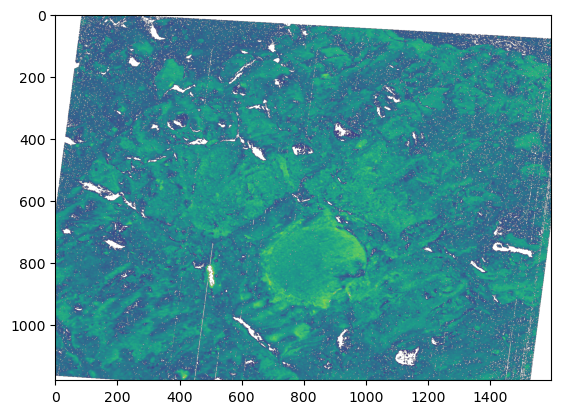

In [18]:
import matplotlib.pyplot as plt

plt.imshow(Classifier.processed_data[2])
plt.show()

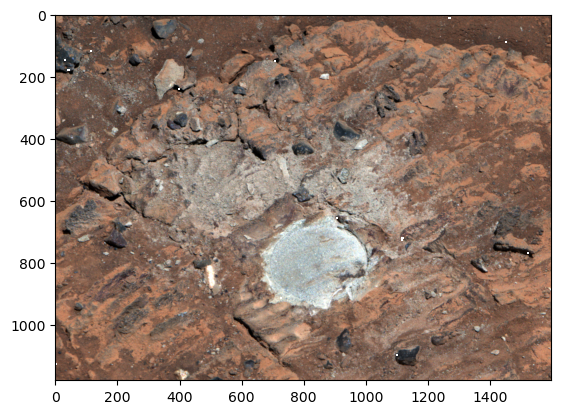

In [8]:
img = Classifier.load_result['rgb_img']
plt.imshow(img)
plt.show()

In [9]:
Classifier.compute_potential_rois(SAM_MODEL_PATH, ROI_KWARGS)

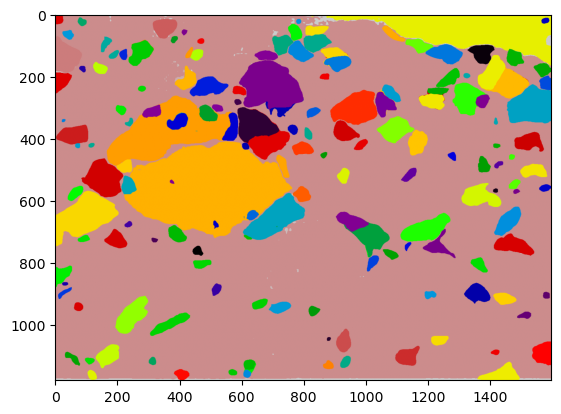

In [10]:
# validate that image segmented properly
mask = Classifier.segments
plt.imshow(mask, cmap="nipy_spectral_r")
plt.show()

In [11]:
Classifier.filter_roi(ROI_AREA_THRESHOLD)

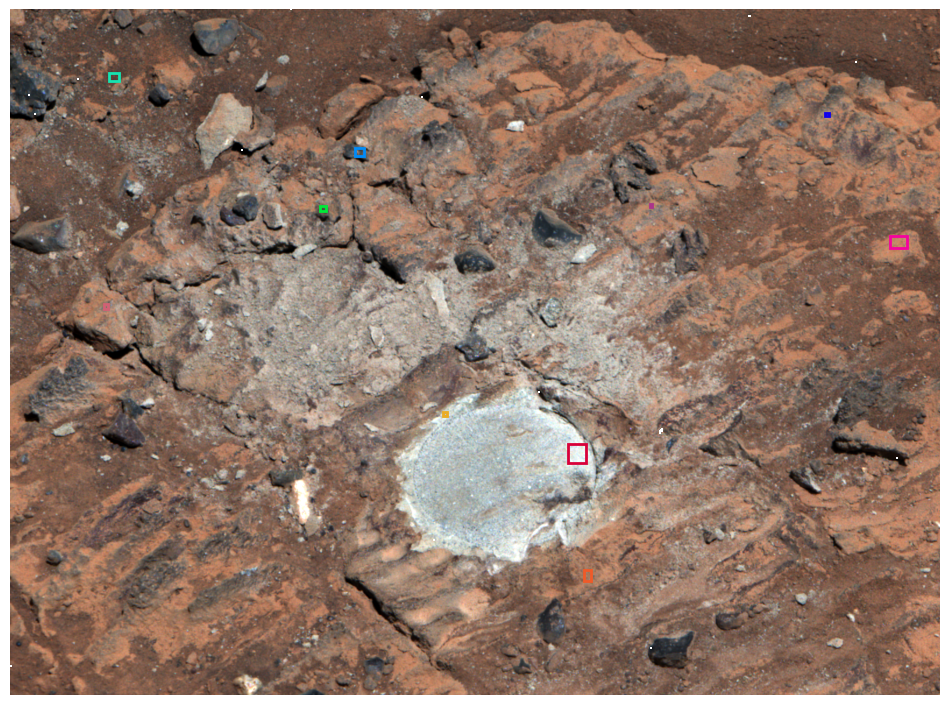

In [12]:
Classifier.show_rois()

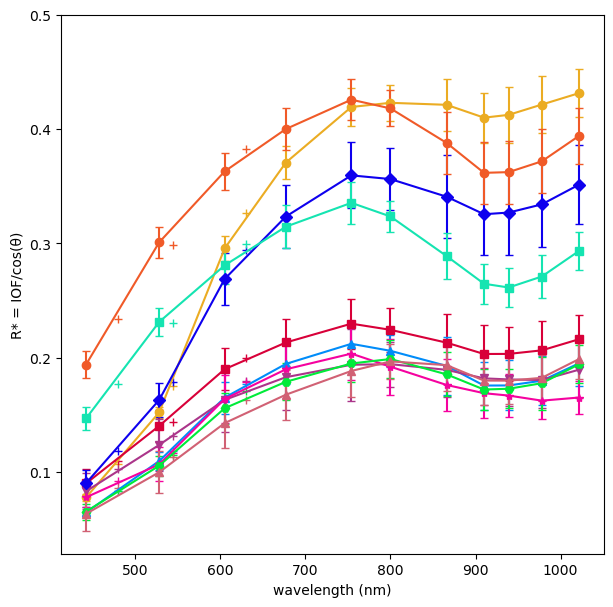

In [13]:
Classifier.show_spectra()